<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1aS4vX-ucDKBmZmZMrBwgjl_DvLAadX2C" width=900/></p>


<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. RAG.

В этом домашнем задании вам предстоит создать туристический RAG, провести EDA и проявить креатив! :)

Вам дан набор данных, содержащий информацию о памятниках, архитектуре и других значимых местах. В данных есть:
* название достопримечательности;
* идентификатор на WikiData;
* город расположения;
* координаты долготы и широты;
* описание (извлеченное из WikiData);
* изображение в формате base64;
* сгенерированное описание изображения (генерация с помощью модели BLIP).

Некоторые из памятников могут встречаться несколько раз, но с различными изображениями, из которых не все могут быть качественными. Для компенсации этого даны текстовые описания.

Часть данных взята с Национальной технологической олимпиады студентов по CV. Базовое решение предполагает использование мультимодального ru-CLIP. Но в данном домашнем задании предлагается решить эту задачу творчески, используя NLP подход.

## Установка и импорт библиотек

In [3]:
!pip install -q accelerate bitsandbytes umap-learn lancedb pyarrow

In [4]:
import base64
import json
import math
import re
from collections import Counter
from dataclasses import dataclass
from io import BytesIO
from typing import List, Optional, Tuple

import lancedb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import torch
from IPython.display import display
from PIL import Image
from sentence_transformers import CrossEncoder, SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.notebook import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, pipeline

## Загрузка данных (4 балла)

In [5]:
data = pd.read_csv('/kaggle/input/datasets/zvictor12/hf-rag-ds/data.csv')

In [6]:
data.head(10)

,Unnamed: 0,Name,WikiData,City,Lon,Lat,description,image,en_txt
0,0,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there are two people that are standing on a tr...
1,1,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed building with a blue and white exterior...
2,2,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
3,3,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
4,4,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a boat that is in the water near a bu...
5,5,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a building with a clock tower in the ...
6,6,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,aerial view of a city with a soccer field and ...
7,7,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,a view of a building with a clock tower on top...
8,8,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed building with a blue and white sign on it
9,9,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed building with a blue and white sign on ...


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14634 entries, 0 to 14633
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   14634 non-null  int64  
 1   Name         14634 non-null  object 
 2   WikiData     12078 non-null  object 
 3   City         14634 non-null  object 
 4   Lon          14634 non-null  float64
 5   Lat          14634 non-null  float64
 6   description  12078 non-null  object 
 7   image        14634 non-null  object 
 8   en_txt       14634 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 1.0+ MB


Для декодирования изображений, закодированных в формате base64, можно использовать следующий код:

In [8]:
import base64
import requests
import matplotlib.pyplot as plt
from PIL import Image
import PIL
from io import BytesIO

In [9]:
def get_image(data):
  image = Image.open(BytesIO(base64.b64decode(data))).convert('RGB')
  return image

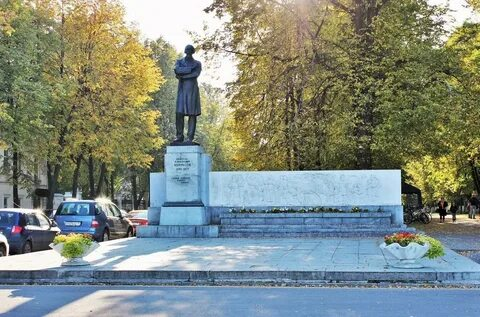

In [10]:
get_image(data.sample(1)['image'].tolist()[0])

В данных есть выбросы — записи, не относящихся к туристическим или историческим объектам. Для очистки данных можно, например, использовать алгоритм TF-IDF: создаем корпус текстов из описаний, применяем TF-IDF, извлекаем наиболее редко или часто встречающиеся слова. Они могут указывать на мусорные данные, такие как мемы, баннеры или личные фото людей. После выделения подозрительных паттернов, можно провести ручную проверку и фильтрацию данных.

Для дальнейшего тестирования и получения чистых сэмплов, рекомендуется взять не менее 100 чистых образцов со стратификацией по городу и названию места. Это можно сделать, выбрав случайным образом несколько образцов из каждой категории (город + название места), чтобы обеспечить равномерное представительство и разнообразие данных.

**!! Важно:** Помните, что чистые сэмплы одного и того же места выдадут примерно одинаковое описание. Есть несколько стратегий, как повысить разнообразие ответов:

- выбор одного самого лучшего:
  - самое длинное описание
  - смое подходящие по мнению LLM
- конкатенация описаний (но важно не сконкатенировать слишком много)

Изображения можно отдать в мета-данные.

Размер данных: (14634, 17)
Уникальных городов: 4
Уникальных пар город+название: 389
Уникальных объектов city+name+wikidata: 390


,missing_count,missing_share
Name,0.0,0.000
WikiData,2556.0,0.175
City,0.0,0.000
description,2556.0,0.175
image,0.0,0.000
en_txt,0.0,0.000
Lon,0.0,0.000
Lat,0.0,0.000


,metric,value
0,rows,14634.0
1,rows_with_wikidata,12078.0
2,rows_with_description,12078.0
3,rows_with_image,14634.0
4,duplicate_rows_by_place_key,14244.0
5,objects_with_multiple_images,390.0
6,median_caption_len,56.0
7,median_description_len,29.0


,Name,WikiData,City,description,en_txt
2360,Доходный дом купца Чувильдина,Q27921892,Екатеринбург,Дом купца Чувильдина,snowy scene of a river and a building with a c...
6561,Дом И. Н. Соболева,Q86684971,Нижний Новгород,Дом И. Н. Соболева,there is a truck parked in front of a building...
12170,Николая Чудотворца,Q4504845,Ярославль,храм в Ярославле,arafed white church with green roof and steepl...
8874,Бобёр,,Владимир,,there are two boys that are posing for a pictu...
12955,Тимерёвский археологический комплекс,Q2494278,Ярославль,Тимерёвский археологический комплекс,there is a sign on the path that says the trai...


,image_b64_len,caption_len,description_len
count,14634.000000,14634.000000,14634.000000
mean,45679.205412,56.503963,26.961323
std,14385.292017,7.513301,21.913780
min,2248.000000,17.000000,0.000000
1%,15451.920000,42.000000,0.000000
5%,22736.000000,46.000000,0.000000
50%,45112.000000,56.000000,27.000000
95%,70112.000000,70.000000,54.000000
99%,80846.760000,77.000000,84.000000
max,376052.000000,130.000000,225.000000


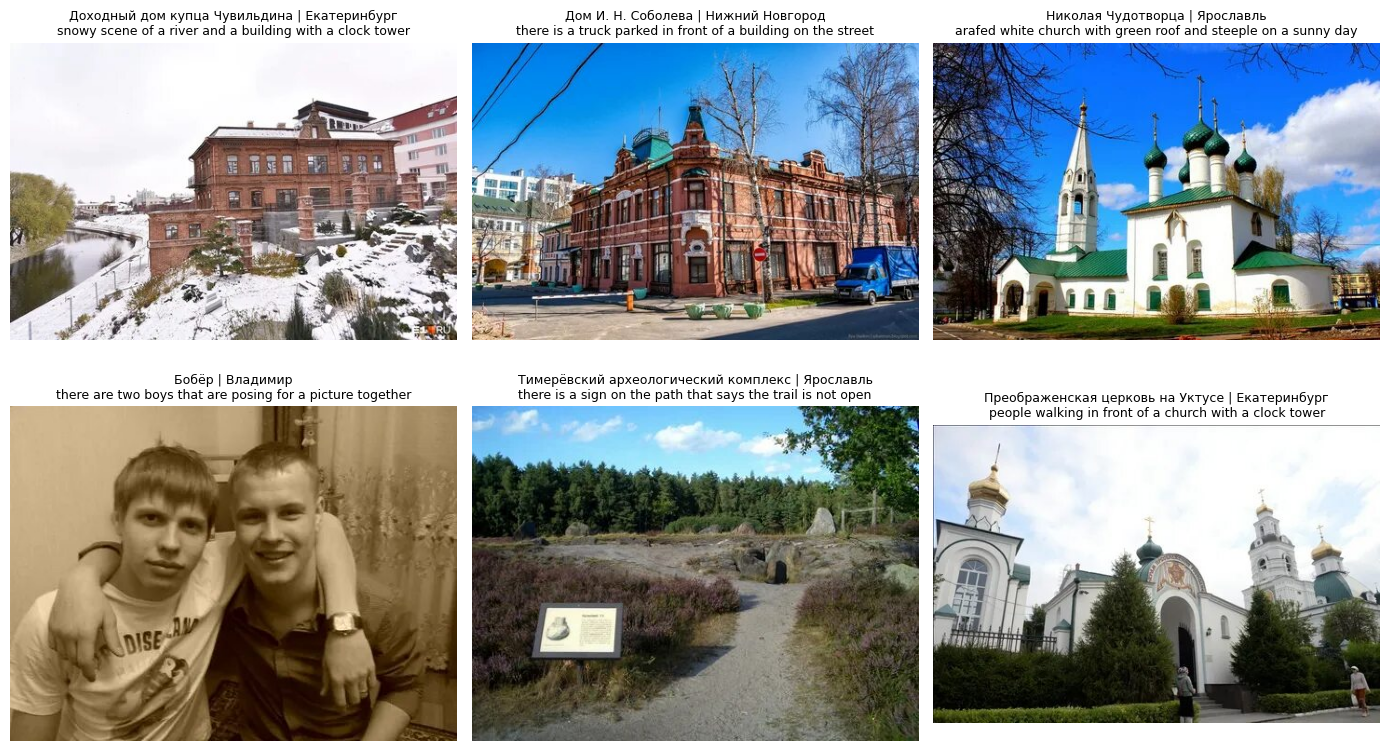

,term,mean_tfidf
297,image,0.045698
119,caption,0.044568
299,image caption,0.044568
730,владимир,0.034746
88,building,0.034114
121,caption arafed,0.033877
25,arafed,0.033877
1941,ярославль,0.032071
731,владимир image,0.029523
963,екатеринбург,0.026996


Подозрительных строк: 1794


,Name,City,description,en_txt
338,Суворовское училище,Екатеринбург,военно-учебное заведение в Екатеринбурге,arafed view of a building with a statue of a m...
341,Суворовское училище,Екатеринбург,военно-учебное заведение в Екатеринбурге,arafed man in a suit and tie standing next to ...
343,Суворовское училище,Екатеринбург,военно-учебное заведение в Екатеринбурге,three men in military uniforms stand in front ...
346,Суворовское училище,Екатеринбург,военно-учебное заведение в Екатеринбурге,arafed group of young boys in uniform posing f...
347,Суворовское училище,Екатеринбург,военно-учебное заведение в Екатеринбурге,arafed group of military men in uniform standi...
348,Суворовское училище,Екатеринбург,военно-учебное заведение в Екатеринбурге,there are many people in uniform standing in a...
350,Суворовское училище,Екатеринбург,военно-учебное заведение в Екатеринбурге,cars parked in front of a large building with ...
352,Суворовское училище,Екатеринбург,военно-учебное заведение в Екатеринбурге,arafed image of a group of men in uniform stan...
353,Суворовское училище,Екатеринбург,военно-учебное заведение в Екатеринбурге,arafed image of a large building with a long t...
354,Суворовское училище,Екатеринбург,военно-учебное заведение в Екатеринбурге,there are many children in uniform marching do...


,quality_score
count,14634.000000
mean,4.350128
std,1.921304
min,-0.500000
25%,4.337500
50%,5.275000
75%,5.412500
max,7.000000


Строк после очистки: (12078, 20)
Уникальных объектов после очистки: 319
Итоговый clean_places: (319, 12)
Размер rag_samples: (100, 12)


,Name,City,description,n_images,quality_score
0,Золотые ворота,Владимир,памятник XII века во Владимире,57,5.3750
1,église arménienne de Vladimir,Владимир,Армянская церковь в г. Владимир России,29,5.4750
2,Владимирская церковь,Ярославль,Владимирская церковь на Божедомке,56,5.4125
3,Свердловский областной краеведческий музей,Екатеринбург,Свердловский областной краеведческий музей,30,5.5250
4,Крестовоздвиженская церковь (Екатеринбург),Екатеринбург,Крестовоздвиженская церковь (Екатеринбург),29,5.5250
5,Князь-Владимирская церковь,Владимир,православный кладбищенский храм во Владимире,56,5.5500
6,Дом Советов,Нижний Новгород,"административное здание в Нижнем Новгороде, Ро...",28,5.6250
7,Музей древнерусского искусства,Ярославль,Митрополичьи палаты (Ярославль),28,5.3875
8,Дом Маева,Екатеринбург,деревянный особняк начала XX века на Вознесенс...,30,5.8875
9,Дом-музей Столетовых,Владимир,"Мемориальный музей в городе Владимире, посвящё...",29,7.0000


In [11]:
RANDOM_STATE = 42
MIN_CLEAN_SAMPLES = 100
MAX_IMAGES_PER_PLACE = 5

work_data = data.copy().drop(columns=['Unnamed: 0'])

for col in ['Name', 'WikiData', 'City', 'description', 'en_txt']:
    work_data[col] = work_data[col].fillna('').astype(str).str.strip()

work_data['has_wikidata'] = work_data['WikiData'].ne('')
work_data['has_description'] = work_data['description'].ne('')
work_data['has_image'] = work_data['image'].fillna('').astype(str).str.len().gt(100)
work_data['image_b64_len'] = work_data['image'].fillna('').astype(str).str.len()
work_data['caption_len'] = work_data['en_txt'].str.len()
work_data['description_len'] = work_data['description'].str.len()

work_data['place_key'] = (
    work_data['City'].str.lower() + '|' +
    work_data['Name'].str.lower() + '|' +
    work_data['WikiData'].str.lower()
)
work_data['name_city_key'] = work_data['City'].str.lower() + '|' + work_data['Name'].str.lower()
work_data['combined_text'] = (
    work_data['Name'] + '. ' + work_data['City'] + '. ' +
    work_data['description'] + '. Image caption: ' + work_data['en_txt']
)

print('Размер данных:', work_data.shape)
print('Уникальных городов:', work_data['City'].nunique())
print('Уникальных пар город+название:', work_data['name_city_key'].nunique())
print('Уникальных объектов city+name+wikidata:', work_data['place_key'].nunique())

missing_report = pd.DataFrame({
    'missing_count': work_data[['Name', 'WikiData', 'City', 'description', 'image', 'en_txt']].eq('').sum(),
    'missing_share': work_data[['Name', 'WikiData', 'City', 'description', 'image', 'en_txt']].eq('').mean().round(3),
})
missing_report.loc['Lon'] = [work_data['Lon'].isna().sum(), round(work_data['Lon'].isna().mean(), 3)]
missing_report.loc['Lat'] = [work_data['Lat'].isna().sum(), round(work_data['Lat'].isna().mean(), 3)]
display(missing_report)

eda_summary = pd.DataFrame({
    'metric': [
        'rows', 'rows_with_wikidata', 'rows_with_description', 'rows_with_image',
        'duplicate_rows_by_place_key', 'objects_with_multiple_images',
        'median_caption_len', 'median_description_len',
    ],
    'value': [
        len(work_data),
        int(work_data['has_wikidata'].sum()),
        int(work_data['has_description'].sum()),
        int(work_data['has_image'].sum()),
        int(work_data.duplicated('place_key').sum()),
        int((work_data.groupby('place_key').size() > 1).sum()),
        float(work_data['caption_len'].median()),
        float(work_data.loc[work_data['description_len'] > 0, 'description_len'].median()),
    ],
})
display(eda_summary)

display(work_data[['Name', 'WikiData', 'City', 'description', 'en_txt']].sample(5, random_state=RANDOM_STATE))

city_counts = work_data['City'].value_counts().head(20).reset_index()
city_counts.columns = ['City', 'count']
fig = px.bar(city_counts, x='City', y='count', title='Top-20 городов по числу строк')
fig.update_layout(xaxis_tickangle=-45)
fig.show()

objects_per_city = (
    work_data.drop_duplicates('place_key')
    .groupby('City')
    .size()
    .sort_values(ascending=False)
    .head(20)
    .reset_index(name='unique_objects')
)
fig = px.bar(objects_per_city, x='City', y='unique_objects', title='Top-20 городов по числу уникальных объектов')
fig.update_layout(xaxis_tickangle=-45)
fig.show()

display(work_data[['image_b64_len', 'caption_len', 'description_len']]
        .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

image_sample = work_data.sample(6, random_state=RANDOM_STATE).reset_index(drop=True)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (_, row) in zip(axes.ravel(), image_sample.iterrows()):
    try:
        ax.imshow(get_image(row['image']))
        ax.set_title(f"{row['Name']} | {row['City']}\n{row['en_txt'][:80]}", fontsize=9)
    except Exception as exc:
        ax.set_title(f"decode error: {exc}", fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

vectorizer = TfidfVectorizer(max_features=2000, ngram_range=(1, 2), min_df=2, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(work_data['combined_text'])
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
top_terms = pd.DataFrame({'term': vectorizer.get_feature_names_out(), 'mean_tfidf': mean_tfidf}) \
    .sort_values('mean_tfidf', ascending=False).head(30)
display(top_terms)

noise_keywords = re.compile(
    r'person|people|man|woman|girl|boy|selfie|group of|crowd|sign|poster|banner|'
    r'food|plate|table|car|bus|train|phone|screen|text|logo',
    flags=re.IGNORECASE,
)
tourist_keywords = re.compile(
    r'музе|памят|собор|церк|храм|монастыр|усадь|театр|площад|улиц|мост|'
    r'парк|сад|крепост|башн|дворец|архитект|здан|дом|комплекс|станц|'
    r'скульптур|обелиск|мемориал|галере|выстав|спорткомплекс|набереж',
    flags=re.IGNORECASE,
)

work_data['caption_has_noise'] = work_data['en_txt'].str.contains(noise_keywords, regex=True)
work_data['text_has_tourist_marker'] = (
    work_data['Name'] + ' ' + work_data['description']
).str.contains(tourist_keywords, regex=True)

suspicious = work_data[work_data['caption_has_noise'] & ~work_data['text_has_tourist_marker']]
print('Подозрительных строк:', len(suspicious))
display(suspicious[['Name', 'City', 'description', 'en_txt']].head(15))

def row_quality_score(row):
    ru_text = f"{row['Name']} {row['description']}"
    score = 0.0
    score += 2.0 if row['has_wikidata'] else 0.0
    score += 1.5 if row['has_description'] else 0.0
    score += min(row['description_len'] / 80, 2.0)
    score += 1.0 if tourist_keywords.search(ru_text) else 0.0
    score += 0.5 if row['has_image'] else 0.0
    score -= 1.0 if row['caption_has_noise'] and not row['text_has_tourist_marker'] else 0.0
    score -= 1.0 if row['caption_len'] < 15 else 0.0
    return score

work_data['quality_score'] = work_data.apply(row_quality_score, axis=1)
display(work_data['quality_score'].describe().to_frame())

clean_rows = work_data[work_data['quality_score'] >= 2.0].copy()
print('Строк после очистки:', clean_rows.shape)
print('Уникальных объектов после очистки:', clean_rows['place_key'].nunique())

def concat_unique(values, max_items=MAX_IMAGES_PER_PLACE):
    seen, result = set(), []
    for value in values:
        value = str(value).strip()
        if value and value.lower() not in seen:
            result.append(value)
            seen.add(value.lower())
        if len(result) >= max_items:
            break
    return ' | '.join(result)

clean_places = (
    clean_rows.sort_values('quality_score', ascending=False)
    .groupby('place_key', as_index=False)
    .agg(
        Name=('Name', 'first'),
        WikiData=('WikiData', 'first'),
        City=('City', 'first'),
        Lon=('Lon', 'first'),
        Lat=('Lat', 'first'),
        description=('description', lambda x: concat_unique(x, max_items=3)),
        en_txt=('en_txt', lambda x: concat_unique(x, max_items=MAX_IMAGES_PER_PLACE)),
        image=('image', 'first'),
        n_images=('image', 'size'),
        quality_score=('quality_score', 'max'),
    )
)

clean_places['document_text'] = clean_places.apply(
    lambda r: (
        f"Объект: {r['Name']} в городе {r['City']}. Точное название объекта: {r['Name']}.\n"
        f"Название: {r['Name']}\n"
        f"Город: {r['City']}\n"
        f"Координаты: {r['Lat']}, {r['Lon']}\n"
        f"WikiData: {r['WikiData']}\n"
        f"Описание: {r['description']}\n"
        f"Визуальные признаки по изображениям: {r['en_txt']}"
    ),
    axis=1,
)

def stratified_place_sample(df, n=MIN_CLEAN_SAMPLES, random_state=RANDOM_STATE):
    if len(df) <= n:
        return df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    per_city = max(1, math.ceil(n / max(df['City'].nunique(), 1)))
    first_pass = df.sort_values('quality_score', ascending=False).groupby('City', group_keys=False).head(per_city)
    if len(first_pass) < n:
        rest = df.drop(first_pass.index, errors='ignore')
        first_pass = pd.concat([first_pass, rest.sample(n=min(n - len(first_pass), len(rest)), random_state=random_state)])
    return first_pass.sample(n=min(n, len(first_pass)), random_state=random_state).reset_index(drop=True)

rag_samples = stratified_place_sample(clean_places, n=MIN_CLEAN_SAMPLES)
print('Итоговый clean_places:', clean_places.shape)
print('Размер rag_samples:', rag_samples.shape)
display(rag_samples[['Name', 'City', 'description', 'n_images', 'quality_score']].head(10))

### Выводы по EDA и очистке данных

После первичного анализа были обнаружены пропуски в `WikiData` и `description`, а также большое число дублей по связке **City + Name + WikiData**.

Для дальнейшего RAG я не использовал все строки как независимые документы, потому что это привело бы к переизбытку почти одинаковых чанков: один и тот же объект мог бы занимать сразу несколько мест в top-k retrieval. Вместо этого строки были агрегированы до уровня уникального объекта.

Здесь предлагаем вам построить RAG с использованием моделей, которые не были представлены на семинаре (включая другие векторные базы данных). Можно воспользоваться материалами по этой ссылке: [data_connection/vectorstores](https://python.langchain.com/v0.1/docs/modules/data_connection/vectorstores/).

!Важно, не забудьте отранжировать чанки текстов с помощью `ragatouille`. На практике порядок текстов в промпте влияет на точность ответа.


### Retrieval и reranking

Первичный поиск выполняется через LanceDB по эмбеддингам модели `intfloat/multilingual-e5-base`. Для этой модели используются специальные префиксы `query:` и `passage:`, так как e5-модели обучались различать запросы и документы именно в таком формате.

После первичного поиска top-k кандидатов применяется reranking. В задании рекомендован `ragatouille`, однако в Kaggle он оказался несовместим с актуальными версиями `LangChain` и `Transformers`. Поэтому вместо него использован multilingual reranker `BAAI/bge-reranker-v2-m3` через `CrossEncoder`. Он решает ту же задачу: оценивает пары `(question, chunk)` и переупорядочивает найденные чанки перед передачей в генератор.

In [12]:
EMBEDDING_MODEL_NAME = 'intfloat/multilingual-e5-base'
GENERATOR_MODEL_NAME = 'Qwen/Qwen2.5-1.5B-Instruct'
RERANKER_MODEL_NAME = 'BAAI/bge-reranker-v2-m3'
MAX_DOCS_FOR_INDEX = 1500
LANCEDB_URI = '/tmp/tourist_lancedb'

@dataclass
class SimpleDocument:
    page_content: str
    metadata: dict


class E5Embedder:
    def __init__(self, model_name: str, batch_size: int = 64):
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.model = SentenceTransformer(model_name, device=device)
        self.batch_size = batch_size

    def embed_documents(self, texts: List[str]) -> List[List[float]]:
        embeddings = self.model.encode(
            texts,
            batch_size=self.batch_size,
            normalize_embeddings=True,
            convert_to_numpy=True,
            show_progress_bar=False,
        )
        return embeddings.tolist()

    def embed_query(self, text: str) -> List[float]:
        embedding = self.model.encode(
            [text],
            batch_size=1,
            normalize_embeddings=True,
            convert_to_numpy=True,
            show_progress_bar=False,
        )[0]
        return embedding.tolist()


def e5_passage(text: str) -> str:
    return 'passage: ' + str(text).replace('\n', ' ')


def e5_query(text: str) -> str:
    return 'query: ' + str(text).replace('\n', ' ')


def split_text(text: str, chunk_size: int = 700, chunk_overlap: int = 120) -> List[str]:
    text = str(text).strip()
    if not text:
        return []
    if len(text) <= chunk_size:
        return [text]

    chunks = []
    start = 0
    separators = ['\n\n', '\n', '. ', '; ', ', ', ' ']

    while start < len(text):
        end = min(len(text), start + chunk_size)
        candidate = text[start:end]
        if end < len(text):
            split_at = -1
            for sep in separators:
                pos = candidate.rfind(sep)
                if pos > chunk_size // 2:
                    split_at = pos + len(sep)
                    break
            if split_at != -1:
                candidate = candidate[:split_at]
                end = start + split_at
        chunks.append(candidate.strip())
        if end >= len(text):
            break
        start = max(start + 1, end - chunk_overlap)
    return chunks


index_places = clean_places.sort_values('quality_score', ascending=False).head(MAX_DOCS_FOR_INDEX).copy()
raw_documents = [
    SimpleDocument(
        page_content=e5_passage(row.document_text),
        metadata={
            'Name': row.Name,
            'City': row.City,
            'WikiData': row.WikiData,
            'Lat': row.Lat,
            'Lon': row.Lon,
            'image': row.image,
            'description': row.description,
        },
    )
    for row in index_places.itertuples(index=False)
]

docs = []
for doc in raw_documents:
    for chunk in split_text(doc.page_content, chunk_size=700, chunk_overlap=120):
        docs.append(SimpleDocument(page_content=chunk, metadata=dict(doc.metadata)))
print('Чанков в индексе:', len(docs))

embedding_model = E5Embedder(EMBEDDING_MODEL_NAME, batch_size=64)

db = lancedb.connect(LANCEDB_URI)
doc_vectors = embedding_model.embed_documents([doc.page_content for doc in docs])
rows = [
    {
        'vector': vector,
        'page_content': doc.page_content,
        'metadata_json': json.dumps(doc.metadata, ensure_ascii=False),
    }
    for doc, vector in zip(docs, doc_vectors)
]
vector_table = db.create_table('tourist_rag', data=rows, mode='overwrite')

reranker = CrossEncoder(
    RERANKER_MODEL_NAME,
    device='cuda' if torch.cuda.is_available() else 'cpu',
)


def strip_e5_prefix(text: str) -> str:
    return text.replace('passage: ', '', 1)


def _rows_to_documents(rows: List[dict]) -> List[SimpleDocument]:
    return [
        SimpleDocument(
            page_content=row['page_content'],
            metadata=json.loads(row['metadata_json']),
        )
        for row in rows
    ]


def retrieve_contexts(question: str, k: int = 5, fetch_k: int = 12):
    query_vector = embedding_model.embed_query(e5_query(question))
    search_rows = vector_table.search(query_vector).metric('cosine').limit(fetch_k).to_list()
    candidate_docs = _rows_to_documents(search_rows)
    if len(candidate_docs) > 1:
        stripped_contents = [strip_e5_prefix(doc.page_content) for doc in candidate_docs]
        scores = reranker.predict([(question, content) for content in stripped_contents])
        order = np.argsort(scores)[::-1][:k]
        return [candidate_docs[i] for i in order]
    return candidate_docs[:k]


def load_generator(model_name: str = GENERATOR_MODEL_NAME):
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_use_double_quant=True,
    )
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        device_map='auto',
        quantization_config=quant_config,
        trust_remote_code=True,
    )
    generator_pipe = pipeline(
    'text-generation',
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=220,
    do_sample=False,
    return_full_text=False,
    )
    generator_pipe.model.generation_config.max_length = None
    return generator_pipe


generator = None


def build_prompt(question: str, contexts: List[SimpleDocument]) -> str:
    context_text = '\n\n'.join(
        f"[{i + 1}] {strip_e5_prefix(doc.page_content)}"
        for i, doc in enumerate(contexts)
    )
    return f"""Ты туристический ассистент по достопримечательностям России.
Отвечай строго на русском языке и только по контексту. Если данных мало, честно скажи, чего не хватает.

Контекст:
{context_text}

Вопрос: {question}
Ответ:"""


def generate_answer(question: str, contexts: List[SimpleDocument], use_llm: bool = True) -> str:
    global generator
    if use_llm:
        if generator is None:
            generator = load_generator()
        output = generator(build_prompt(question, contexts))[0]['generated_text']
        return output.strip()
    best = contexts[0].metadata if contexts else {}
    if not best:
        return 'Не удалось найти релевантный объект в базе.'
    return (
        f"{best.get('Name')} находится в городе {best.get('City')}. "
        f"Краткое описание: {best.get('description')}"
    )


def tourist_rag(question: str, k: int = 5, use_llm: bool = True):
    contexts = retrieve_contexts(question, k=k)
    answer = generate_answer(question, contexts, use_llm=use_llm)
    return {
        'question': question,
        'answer': answer,
        'contexts': [strip_e5_prefix(doc.page_content) for doc in contexts],
        'metadata': [doc.metadata for doc in contexts],
    }

example_question = 'Какие интересные архитектурные объекты можно посмотреть в Екатеринбурге?'
example_retrieval = tourist_rag(example_question, k=3, use_llm=False)
print(example_retrieval['answer'])
display(pd.DataFrame(example_retrieval['metadata'])[['Name', 'City', 'WikiData']])

Чанков в индексе: 335


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

Иоанно-Предтеченский Кафедральный собор находится в городе Екатеринбург. Краткое описание: церковь в Екатеринбурге


,Name,City,WikiData
0,Иоанно-Предтеченский Кафедральный собор,Екатеринбург,Q4202547
1,Белая башня,Екатеринбург,Q4081645
2,Александро-Невская часовня,Екатеринбург,Q54901778


Выполните визуализацию эмбеддингов при помощи метода главных компонент (PCA) и Uniform Manifold Approximation and Projection (UMAP). Пожалуйста, выполните PCA независимо от pacmap.

In [13]:
viz_places = clean_places.sample(n=min(500, len(clean_places)), random_state=RANDOM_STATE).reset_index(drop=True)
viz_texts = [e5_passage(text) for text in viz_places['document_text'].tolist()]
viz_embeddings = np.asarray(embedding_model.embed_documents(viz_texts))

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_points = pca.fit_transform(viz_embeddings)
viz_places['pca_1'] = pca_points[:, 0]
viz_places['pca_2'] = pca_points[:, 1]

fig = px.scatter(
    viz_places,
    x='pca_1',
    y='pca_2',
    color='City',
    hover_data=['Name', 'City', 'description'],
    title=f'PCA эмбеддингов, explained variance={pca.explained_variance_ratio_.sum():.2f}',
)
fig.show()

import umap
umap_reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.05, metric='cosine', random_state=RANDOM_STATE)
umap_points = umap_reducer.fit_transform(viz_embeddings)
viz_places['umap_1'] = umap_points[:, 0]
viz_places['umap_2'] = umap_points[:, 1]

fig = px.scatter(
    viz_places,
    x='umap_1',
    y='umap_2',
    color='City',
    hover_data=['Name', 'City', 'description'],
    title='UMAP эмбеддингов документов',
)
fig.show()

2026-05-05 18:13:38.964924: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778004819.388623      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778004819.494764      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778004820.455467      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778004820.455509      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778004820.455514      57 computation_placer.cc:177] computation placer alr

# RAGAS (3 балла)

RAGAS - это система, созданная для автоматической оценки эффективности модели RAG. Она представляет собой комплексный инструмент, способный оценить как качество извлечения информации, так и качество созданного текста. Это достигается благодаря использованию различных метрик, которые анализируют разные аспекты ответов, сгенерированных языковой моделью.



## Метрики оценки в RAGAS

### Faithfulness
Оценивает, насколько ответы языковой модели верно передают информацию, содержащуюся в источниках данных. Это критически важно, чтобы гарантировать, что модель не искажает или не меняет информацию при её интерпретации.

---

$
Faithfulness = \frac{\text{|Number of claims that can be inferred from given context|}}{\text{|Total number of claims in the generated answer|}}
$

### Answer Relevancy
Демонстрирует, насколько ответы соответствуют заданным вопросам. Это важный аспект, так как даже правильный ответ с технической точки зрения может быть ненужным, если он не отвечает на конкретный вопрос пользователя.

---

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} cos(E_{g_i}, E_o)$

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} \frac{E_{g_i} \cdot E_o}{\|E_{g_i}\|\|E_o\|}$

Где:

* $E_{g_i}$ - это эмбеддинг сгенерированного ответа $i$

* $E_o$ - это эмбеддинг исходного вопроса.

* $N$ - это количество сгенерированных вопросов, которое по умолчанию равно 3.

### Context Recall и Context Precision
Эти метрики измеряют эффективность модели в учете контекста вопроса для формирования ответа. "Context Recall" оценивает количество использованной информации из контекста в ответе, в то время как "Context Precision" оценивает точность и релевантность использования контекстной информации.

---

* $ \text{context recall} = \frac{\text{|GT sentences that can be attributed to context|}}{\text{|Number of sentences in GT|}} $
* $Context Precision@k = \frac{\sum \text{precision@k}}{\text{total number of relevant items in the top K results}}$
  * $Precision@k = \frac{\text {true positives@k}}{\text{(true positives@k + false positives@k)}}$

### Answer Semantic Similarity
Оценивает степень семантической близости между ответом модели и эталонным ответом. Это позволяет определить, насколько естественно и точно модель способна воссоздавать человеческий язык.

### Answer Correctness
Оценка корректности ответа. Это последний шаг в проверке, чтобы убедиться, предоставляет ли модель точную и достоверную информацию в своем ответе.

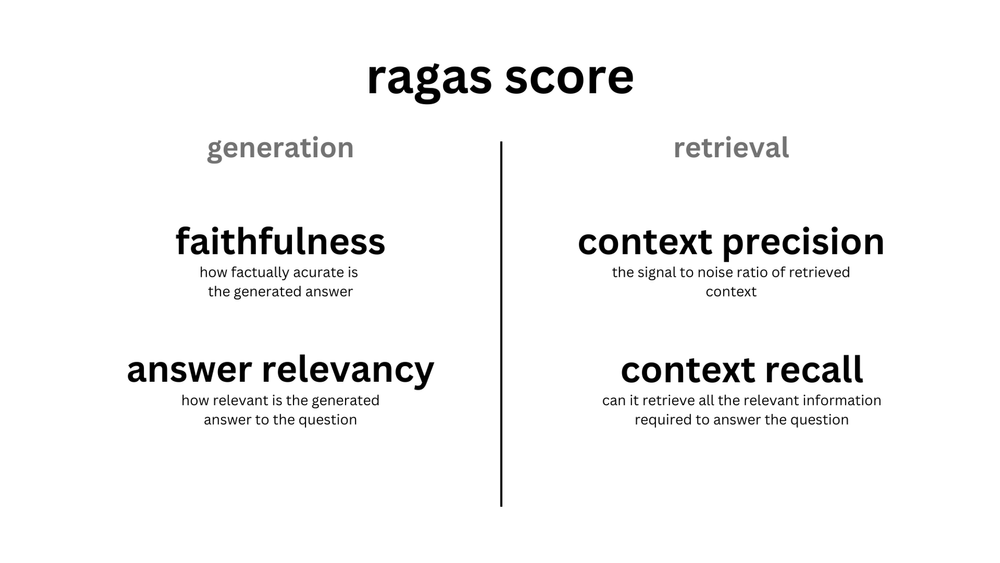

В этом задании вам нужно реализовать метрику answer_relevancy в коде. Опционально за допбаллы можно реализовать другие метрики.

Для этого датасет нужно привести к виду, в котором будут следующие поля:

### 1. question
- Смысл: Эта колонка содержит вопросы, на которые нужно найти ответы. В контексте задач QA, это основная информация, которую модель должна обработать для генерации ответа.
- Пример: "Каковы преимущества RAG?"

### 2. ground_truths
- Смысл: В этой колонке находятся правильные ответы на соответствующие вопросы. Это может использоваться для оценки производительности модели, так как позволяет сравнить сгенерированные ответы с эталонными.
- Пример: "RAG улучшает качество генерации, используя внешние источники информации."

### 3. answer
- Смысл: Эта колонка содержит ответы, которые генерирует модель на основе заданных вопросов. Это может быть результат работы модели, которую вы тестируете или обучаете.
- Пример: "RAG позволяет моделям извлекать информацию из внешних источников, что улучшает их способность отвечать на сложные вопросы."

### 4. contexts
- Смысл: Эта колонка предоставляет контекст или дополнительную информацию, которая может быть полезна для понимания вопроса или для формирования ответа. Это может быть текст, из которого был извлечен ответ, или другие релевантные документы.
- Пример: "RAG (Retrieval-Augmented Generation) — это метод, который использует внешние базы данных для получения информации при генерации текста."

HINT: Поле question можно тоже сгенерировать. Например, можно попросить модель задать вопрос по описанию изображения.

HINT: Для answer_relevancy нужны не все поля

HINT: Инференс такого эксперимента может быть долгим. План минимум: возьмите 100 случайных сэмплов.

In [14]:
def make_question(row) -> str:
    name = row.get('Name', 'объект')
    city = row.get('City', '')
    if city:
        return f"Найди достопримечательность с названием «{name}» в городе {city}. Что это за объект?"
    return f"Найди достопримечательность с названием «{name}». Что это за объект?"


def data_preprocess(
    samples_df: pd.DataFrame,
    n_samples: int = 100,
    use_llm: bool = False,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    eval_rows = samples_df.sample(n=min(n_samples, len(samples_df)), random_state=random_state).reset_index(drop=True)
    records = []
    for row in tqdm(eval_rows.to_dict('records')):
        question = make_question(row)
        rag_result = tourist_rag(question, k=5, use_llm=use_llm)
        ground_truth = (
            f"{row['Name']} находится в городе {row['City']}. "
            f"Описание: {row['description']}. "
            f"Координаты: {row['Lat']}, {row['Lon']}."
        )
        records.append({
            'question': question,
            'ground_truths': [ground_truth],
            'answer': rag_result['answer'],
            'contexts': rag_result['contexts'],
            'expected_wikidata': row.get('WikiData', ''),
            'retrieved_wikidata': [m.get('WikiData', '') for m in rag_result['metadata']],
        })
    return pd.DataFrame(records)

In [15]:
import json

def _parse_questions_from_llm_output(text: str, n: int = 3) -> List[str]:
    text = str(text).strip()

    try:
        start, end = text.find('['), text.rfind(']')
        if start != -1 and end != -1 and end > start:
            parsed = json.loads(text[start:end + 1])
            questions = [str(x).strip() for x in parsed if str(x).strip()]
            if questions:
                return questions[:n]
    except Exception:
        pass

    questions = []
    for line in text.splitlines():
        line = re.sub(r'^\s*[-*\d.)]+\s*', '', line).strip().strip('"')
        if line.endswith('?') and len(line) > 10:
            questions.append(line)

    if questions:
        return questions[:n]

    return [p.strip() + '?' for p in text.split('?') if len(p.strip()) > 10][:n]


def _question_variants_from_answer(
    answer: str,
    n: int = 3,
    use_llm_question_generation: bool = True,
) -> List[str]:
    answer = str(answer).strip()
    if not answer:
        return []

    if use_llm_question_generation:
        global generator
        if generator is None:
            generator = load_generator()

        prompt = f"""Ты оцениваешь RAG-систему. По данному ответу сгенерируй {n} разных вопроса на русском языке, на которые этот ответ мог бы отвечать.
Верни только JSON-список строк, без пояснений.

Ответ:
{answer[:1200]}

JSON:"""

        try:
            raw_output = generator(
                prompt,
                max_new_tokens=180,
                do_sample=False,
                temperature=0.0,
                return_full_text=False,
            )[0]['generated_text']

            questions = _parse_questions_from_llm_output(raw_output, n=n)
            if questions:
                return questions[:n]
        except Exception as exc:
            print('LLM question generation fallback:', repr(exc))

    first_sentence = re.split(r'(?<=[.!?])\s+', answer)[0]
    return [
        f"О каком туристическом объекте говорится в ответе: {first_sentence}",
        f"Какую достопримечательность можно описать так: {first_sentence}",
        f"Какая информация запрашивалась, если ответ был таким: {answer[:220]}",
    ][:n]


def answer_relevancy(
    eval_df: pd.DataFrame,
    embedder=embedding_model,
    n_generated_questions: int = 3,
    use_llm_question_generation: bool = True,
) -> Tuple[float, pd.DataFrame]:
    rows = []

    for item in tqdm(eval_df.to_dict('records')):
        question = item['question']
        answer = item['answer']

        generated_questions = _question_variants_from_answer(
            answer,
            n=n_generated_questions,
            use_llm_question_generation=use_llm_question_generation,
        )

        if not generated_questions:
            rows.append({
                'question': question,
                'answer': answer,
                'generated_questions': [],
                'answer_relevancy': 0.0,
            })
            continue

        q_emb = np.asarray(embedder.embed_query(e5_query(question))).reshape(1, -1)
        gen_emb = np.asarray(embedder.embed_documents([e5_query(q) for q in generated_questions]))
        sims = cosine_similarity(gen_emb, q_emb).ravel()

        rows.append({
            'question': question,
            'answer': answer,
            'generated_questions': generated_questions,
            'answer_relevancy': float(np.mean(sims)),
        })

    details = pd.DataFrame(rows)
    return float(details['answer_relevancy'].mean()), details

# Протестируйте ваш RAG (3 балла)

In [16]:
RUN_LLM_DEMO = torch.cuda.is_available()
RUN_LLM_EVAL = True  

test_questions = [
    'Что можно посмотреть туристу в Екатеринбурге из архитектурных объектов?',
    'Расскажи про интересный памятник или мемориал в Москве.',
    'Какая достопримечательность связана с религиозной архитектурой в Санкт-Петербурге?',
]

for question in test_questions:
    result = tourist_rag(question, k=5, use_llm=RUN_LLM_DEMO)
    print('\nВОПРОС:', question)
    print('ОТВЕТ:', result['answer'])
    display(pd.DataFrame(result['metadata'])[['Name', 'City', 'WikiData']].head())

eval_dataset = data_preprocess(rag_samples, n_samples=100, use_llm=RUN_LLM_EVAL)
relevancy_score, relevancy_details = answer_relevancy(
    eval_dataset,
    use_llm_question_generation=True,
)

print('Answer relevancy:', round(relevancy_score, 4))
display(relevancy_details.head())

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Both `max_new_tokens` (=220) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=220) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=220) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=220) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

  0%|          | 0/100 [00:00<?, ?it/s]

Passing `generation_config` together with generation-related arguments=({'temperature', 'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_c

Answer relevancy: 0.838


,question,answer,generated_questions,answer_relevancy
0,Найди достопримечательность с названием «Музей...,Музей-квартира А.М. Горького находится в город...,[Какое место в Нижнем Новгороде называется Муз...,0.925247
1,Найди достопримечательность с названием «Церко...,Церковь в честь Преображения Господня находитс...,"[Какова история церкви?, Что делает церковь ос...",0.781603
2,Найди достопримечательность с названием «Яросл...,Ярославский художественный музей (Губернаторск...,"[[]\n[""Каковы особенности художественного музе...",0.815355
3,Найди достопримечательность с названием «Дом-м...,Дом-музей Ф.М. Решетникова находится в Екатери...,"[{""question"": ""Куда можно поехать?, "", ""answer...",0.829540
4,Найди достопримечательность с названием «Крест...,"Достопримечательность с названием ""Крестовоздв...","[Какова история этого монастыря?, Где находитс...",0.831937


# Дополнительная часть (+3 балла)

Реализуйте одну из метрик retrieval-части на выбор.

Для того, чтобы понять model as a judge подход из RAGAS, советуем посетить [этот кукбук](https://huggingface.co/learn/cookbook/en/rag_evaluation)

In [17]:
def context_precision_at_k(eval_df: pd.DataFrame, k: int = 5) -> Tuple[float, pd.DataFrame]:
    rows = []
    for item in eval_df.to_dict('records'):
        expected = item.get('expected_wikidata', '')
        retrieved = item.get('retrieved_wikidata', [])[:k]
        hits = [int(w == expected and expected != '') for w in retrieved]
        precision = sum(hits) / max(len(retrieved), 1)
        rows.append({
            'question': item['question'],
            'expected_wikidata': expected,
            f'context_precision@{k}': precision,
            'hit_at_1': hits[0] if hits else 0,
            f'hit_at_{k}': int(any(hits)),
        })
    details = pd.DataFrame(rows)
    return float(details[f'context_precision@{k}'].mean()), details


def mrr_at_k(eval_df: pd.DataFrame, k: int = 5) -> Tuple[float, pd.DataFrame]:
    rows = []
    for item in eval_df.to_dict('records'):
        expected = item.get('expected_wikidata', '')
        retrieved = item.get('retrieved_wikidata', [])[:k]
        reciprocal_rank = 0.0
        for rank, wikidata in enumerate(retrieved, start=1):
            if wikidata == expected and expected != '':
                reciprocal_rank = 1.0 / rank
                break
        rows.append({'question': item['question'], f'mrr@{k}': reciprocal_rank})
    details = pd.DataFrame(rows)
    return float(details[f'mrr@{k}'].mean()), details

cp_score, cp_details = context_precision_at_k(eval_dataset, k=5)
mrr_score, mrr_details = mrr_at_k(eval_dataset, k=5)
print('Context Precision@5:', round(cp_score, 4))
print('MRR@5:', round(mrr_score, 4))
display(cp_details.head())

Context Precision@5: 0.228
MRR@5: 0.99


,question,expected_wikidata,context_precision@5,hit_at_1,hit_at_5
0,Найди достопримечательность с названием «Музей...,Q4306041,0.2,1,1
1,Найди достопримечательность с названием «Церко...,Q104776528,0.2,1,1
2,Найди достопримечательность с названием «Яросл...,Q3329597,0.4,1,1
3,Найди достопримечательность с названием «Дом-м...,Q4263806,0.2,1,1
4,Найди достопримечательность с названием «Крест...,Q4240402,0.4,1,1


### Выводы по метрикам

`Answer relevancy` получился высоким, что означает семантическую близость ответов к исходным вопросам. Модель в большинстве случаев отвечает по теме и использует найденный контекст.

`MRR@5` близок к 1, значит релевантный объект почти всегда оказывается на первой позиции после retrieval и reranking. Это показывает, что связка multilingual embeddings + multilingual reranker хорошо справляется с поиском нужной достопримечательности.

`Context Precision@5` ниже, потому что метрика считается строго по `WikiData`: релевантным считается только тот чанк, который относится к точному объекту из вопроса. При top-5 выдаче обычно существует один правильный объект и несколько похожих объектов из того же города или той же категории, поэтому precision@5 ограничен.